# Hadron AQC — the trainable circuit, built by hand

What IBM's library (`generate_ansatz_from_circuit`) does inside, rebuilt by hand for the 12-qubit hadron circuit at 2 cheap steps.
The main notebook (`hadron-aqc-tebd.ipynb`) uses the library; this one is kept for understanding, and as the place to try block changes (e.g. holding angles at zero to save CNOTs).

Checked: same 147 CNOTs and the same before-training scores (0.5999 vacuum / 0.7152 meson) as the library.

1. Read the two-qubit gates (brickwork)
2. Build the trainable circuit by hand

In [1]:
# Setup
import numpy as np
from qiskit import QuantumCircuit
from hadron_aqc_utils import construct_circuit, aqc_triplet_block, aqc_init_layer, aqc_field_layer

n_sites = 6
num_qubits = 2 * n_sites

## Step 1 — Read the two-qubit gates (brickwork): `build_hadron_brickwork_gate_info`

**Think of `construct_circuit` as a list of instructions**, carried out one after another. Each instruction is one of two kinds:

- **touches one qubit**: an X flip at the start, or an Rz turn at the end of each step
- **touches two neighbouring qubits**: a pair gate, a swap, or an electric gate

**What `build_hadron_brickwork_gate_info` does:** it goes through the same instructions in the same order, **skips the one-qubit ones**, and **writes down each two-qubit one** as "which two qubits, which kind".

Tiny example with 2 sites (4 qubits) and 1 step. `construct_circuit` does:

1. flip qubit 1, flip qubit 3 *(one-qubit, skipped)*
2. pair gate on qubits 0 and 1 → written down
3. pair gate on qubits 2 and 3 → written down
4. swap on qubits 1 and 2 → written down
5. electric gate on qubits 0 and 1 → written down
6. electric gate on qubits 2 and 3 → written down
7. Rz turn on each qubit *(one-qubit, skipped)*

So `build_hadron_brickwork_gate_info` returns:

```
pair on (0,1), pair on (2,3), swap on (1,2), electric on (0,1), electric on (2,3)
```

For our real case (6 sites, 2 steps) the list has 49 entries.

**Why we need this list:** the trainable circuit is built by **replacing each two-qubit gate with a trainable block** (a triplet block, whose angles can be adjusted). For every two-qubit gate we need:

- **where** it is (which two qubits, and in what order), so the trainable block goes in the same place
- **what** it was (pair, swap or electric), so we know what the block should start out copying

We don't need to understand *why* `construct_circuit` puts the gates where it does. We only copy the positions, not the reasons.

**Spotting each gate in the circuit drawing:**

- **Pair gate**: red **H** boxes, Rz angles **±0.15** (`kinetic_strength`), 4 CNOTs.
- **Swap**: two **✕** marks joined by a line.
- **Electric gate**: two dark **X** boxes on the same (even) qubit, one before and one after, with 2 CNOTs between them. The Rz angles are tiny, **±0.005** (half of `electric_field_strength` = 0.01).
- **One-qubit gates, not bricks**: the X boxes alone at the far left (starting flips), and the Rz **±0.03** at the end of each step (`mass`).


hadron circuit 
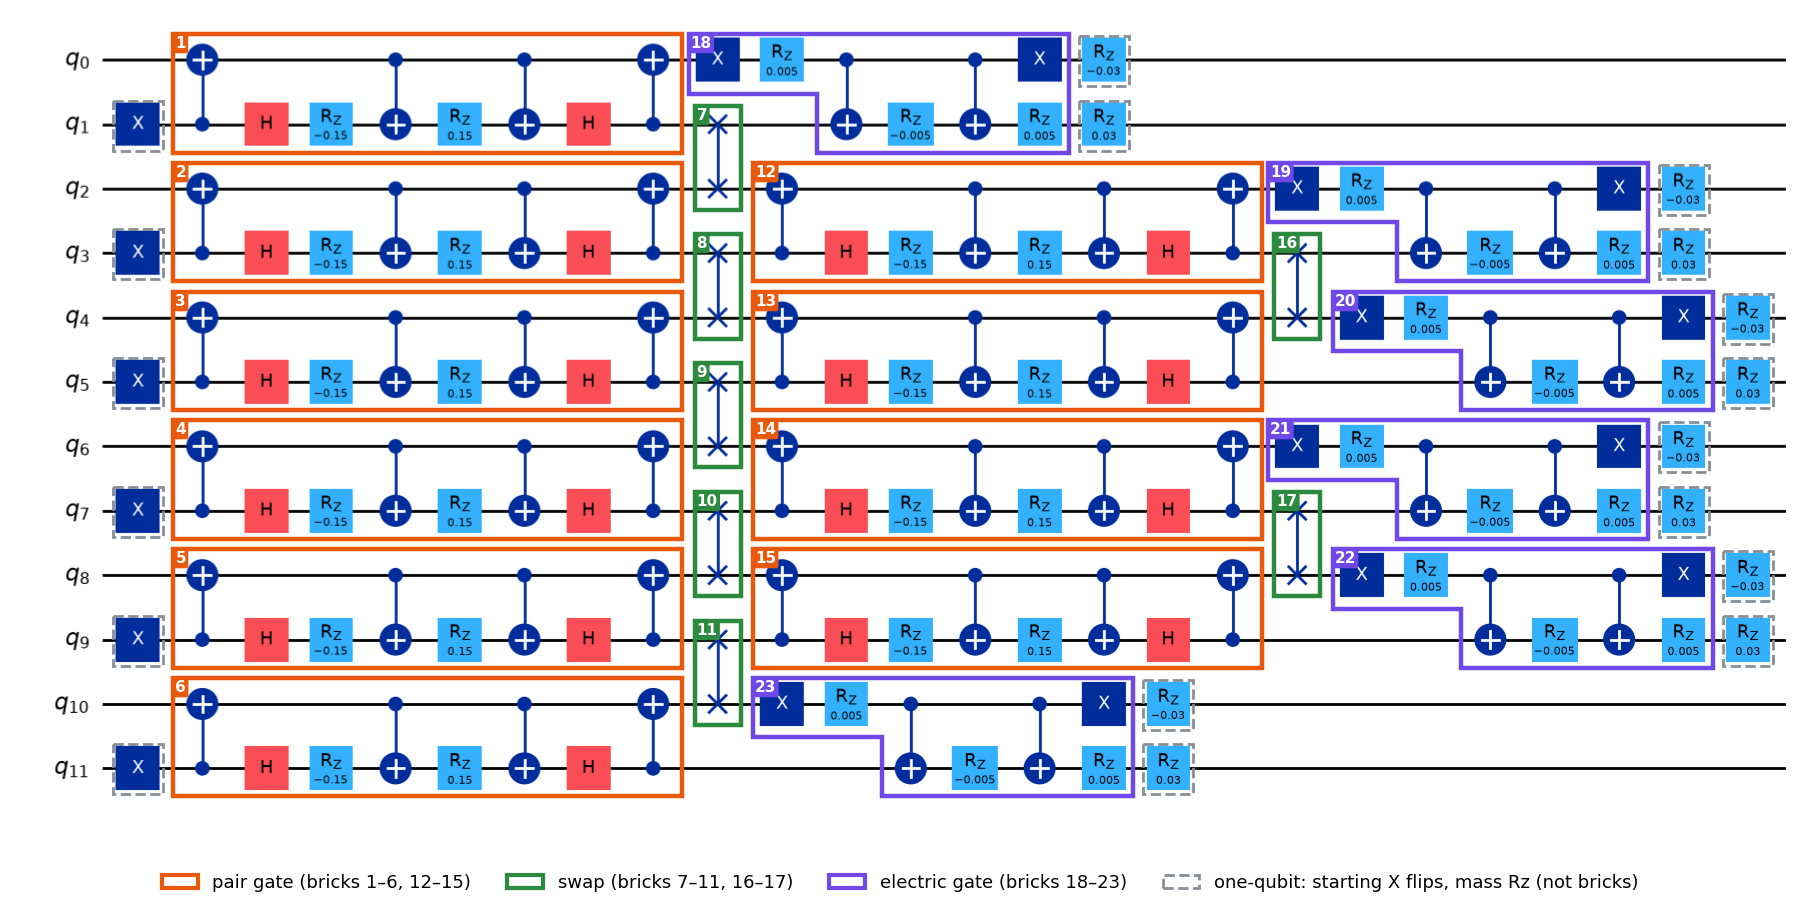




In [2]:
# Step 1 — read the two-qubit gates out of construct_circuit

num_coarse_steps = 2
kinetic_strength = 0.15
electric_field_strength = 0.01
mass = 0.03
num_trotter_steps = 10

strength_scale = num_trotter_steps / num_coarse_steps

def build_hadron_brickwork_gate_info(hadron_trotter_circuit):
    brickwork = []
    for instruction in hadron_trotter_circuit.data:
        gate_name = instruction.operation.name
        if gate_name in ["pair", "swap", "electric"]:
            qubit_a = hadron_trotter_circuit.find_bit(instruction.qubits[0]).index
            qubit_b = hadron_trotter_circuit.find_bit(instruction.qubits[1]).index
            brickwork.append((qubit_a, qubit_b, gate_name))

    return brickwork        

coarse_hadron_trotter_circuit = construct_circuit(n_sites, num_coarse_steps,
                                                  kinetic_strength * strength_scale,
                                                  electric_field_strength * strength_scale,
                                                  mass * strength_scale,
                                                  keep_gates_as_blocks=True)

coarse_brickwork = build_hadron_brickwork_gate_info(coarse_hadron_trotter_circuit)

for brick_num, brick in enumerate(coarse_brickwork, start=1):
    print(brick_num, brick)
print(f"{len(coarse_brickwork)} bricks")


1 (0, 1, 'pair')
2 (2, 3, 'pair')
3 (4, 5, 'pair')
4 (6, 7, 'pair')
5 (8, 9, 'pair')
6 (10, 11, 'pair')
7 (1, 2, 'swap')
8 (3, 4, 'swap')
9 (5, 6, 'swap')
10 (7, 8, 'swap')
11 (9, 10, 'swap')
12 (2, 3, 'pair')
13 (4, 5, 'pair')
14 (6, 7, 'pair')
15 (8, 9, 'pair')
16 (3, 4, 'swap')
17 (7, 8, 'swap')
18 (0, 1, 'electric')
19 (2, 3, 'electric')
20 (4, 5, 'electric')
21 (6, 7, 'electric')
22 (8, 9, 'electric')
23 (10, 11, 'electric')
24 (1, 2, 'swap')
25 (5, 6, 'swap')
26 (9, 10, 'swap')
27 (0, 1, 'pair')
28 (2, 3, 'pair')
29 (4, 5, 'pair')
30 (6, 7, 'pair')
31 (8, 9, 'pair')
32 (10, 11, 'pair')
33 (1, 2, 'swap')
34 (3, 4, 'swap')
35 (5, 6, 'swap')
36 (7, 8, 'swap')
37 (9, 10, 'swap')
38 (2, 3, 'pair')
39 (4, 5, 'pair')
40 (6, 7, 'pair')
41 (8, 9, 'pair')
42 (3, 4, 'swap')
43 (7, 8, 'swap')
44 (0, 1, 'electric')
45 (2, 3, 'electric')
46 (4, 5, 'electric')
47 (6, 7, 'electric')
48 (8, 9, 'electric')
49 (10, 11, 'electric')
49 bricks


## Step 2 — Build the trainable circuit by hand: `build_aqc_hadron_circuit`

**Main rule:** every two-qubit gate (a *brick*) is replaced by **one triplet block**, whatever its kind. A pair gate has 8 pieces and an electric gate has 7, but all of them act on the same two qubits, so each one is **one** two-qubit gate (one 4×4 matrix). Any two-qubit gate can be rebuilt from 3 CNOTs plus one-qubit turns, and a triplet block is exactly that.

### Table 1 — gate by gate: hadron circuit → AQC circuit

| hadron circuit (`construct_circuit`) | Algorithm 1 equivalent (XYZ, `second_order_trotter_circuit`) | replaced in AQC by | function | angles | CNOTs | starting angles (the library computes these) |
|---|---|---|---|---|---|---|
| **X flips** at the start (qubits 1, 3, 5, 7, 9, 11 for vacuum) | Néel state built into the starting MPS (`get_Neel_State_as_mps`), no gates | **init layer**: Rz, Ry, Rz on every qubit | `aqc_init_layer` | 3 per qubit | 0 | Ry = π on flipped qubits (turns 0 into 1), all else 0 |
| **pair gate**: CX, H, Rz, CX, Rz, CX, H, CX, 4 CNOTs | **bond gate** (one two-qubit gate) | **1 triplet block** | `aqc_triplet_block` | 12 | 3 | computer search: triplet ≈ pair gate |
| **swap** (✕–✕), 3 CNOTs | none (XYZ has no swaps) | **1 triplet block** | `aqc_triplet_block` | 12 | 3 | all 12 = 0 (a zero-angle triplet *is* a swap) |
| **electric gate**: X, Rz, CX, Rz, CX, Rz, X, 2 CNOTs | none (XYZ has no electric gate) | **1 triplet block** | `aqc_triplet_block` | 12 | 3 | computer search: triplet ≈ electric gate |
| **mass Rz** between step 1 and step 2 | Rz field turns between layers (`h`) | **2 Rz turns in front of the next brick** on those qubits | `qc.rz` (lines 9–10 of 1.3b) | 2 per brick | 0 | the carried mass turn, else 0 |
| **mass Rz** at the very end | none (Algorithm 1 had no field layer after the last layer) | **final field layer**: one Rz per qubit | `aqc_field_layer` | 1 per qubit | 0 | the last mass turns |

### Table 2 — what is inside a triplet block (the nesting)

| level | what it is | made of |
|---|---|---|
| **brick** | one pair gate / swap / electric gate in the hadron circuit | — |
| **triplet block** (`aqc_triplet_block`) | replaces one brick | 3 CNOT blocks in a row |
| **CNOT block** (`aqc_cnot_block`) | a piece of the triplet; replaces nothing on its own | 1 CNOT + 4 one-qubit turns |

### Table 3 — function names: Algorithm 1 → this notebook

| job | Algorithm 1 (XYZ) | this notebook (hadron) |
|---|---|---|
| Trotter circuit | `second_order_trotter_circuit` | `construct_circuit` |
| starting state | `get_Neel_State_as_mps` (Néel) | `zero_state_mps` (all \|0⟩, the X flips are in the circuit) |
| where the bricks are | `build_aqc_pair_layers` (even/odd pairs, alternating) | `build_hadron_brickwork_gate_info` (read from the circuit) |
| trainable circuit | `aqc_parametrized_circuit` | `build_aqc_hadron_circuit` |
| angle lists | three lists + `pack_thetas` / `unpack_thetas` | one flat list, read in order with a `position` bookmark |
| starting angles | `trotter_aqc_init_params` (by formula) | the library (`generate_ansatz_from_circuit`) |
| cost + training | `aqc_cost_tebd_mps` + `minimize` | the library (`MaximizeStateFidelity`) + `minimize` |

### Table 4 — totals for the 2-step AQC circuit (49 bricks)

| part | count | angles |
|---|---|---|
| init layer | 12 qubits × 3 | 36 |
| Rz turns in front of bricks | 49 × 2 | 98 |
| triplet blocks | 49 × 12 | 588 |
| final field layer | 12 × 1 | 12 |
| **total** | | **734 angles, 147 CNOTs** |

For comparison: the plain 2-step circuit has 155 CNOTs (fidelity 0.60 vacuum / 0.72 meson), and the 10-step target circuit has 811 (611 after Qiskit optimisation). The gain comes from **training**, which makes 147 CNOTs almost as accurate as the deep circuit.

In [3]:
# Step 2 — build the trainable circuit by hand
def build_aqc_hadron_circuit(num_qubits, brickwork, aqc_thetas):
    qc = QuantumCircuit(num_qubits)
    position = 0 # to move on the single list of thetas
    #init layer 3 gates per qubit 
    init_thetas = aqc_thetas[position : position + 3 * num_qubits]
    qc.compose(aqc_init_layer(num_qubits, init_thetas), range(num_qubits), inplace=True)
    position += 3 * num_qubits

    # every brick (pair/swap/electric)
    for qubit_a, qubit_b, gate_name in brickwork:
        qc.rz(aqc_thetas[position], qubit_a)
        qc.rz(aqc_thetas[position + 1], qubit_b)
        position += 2
        triplet_thetas = aqc_thetas[position: position+12]
        qc.compose(aqc_triplet_block(triplet_thetas), [qubit_a, qubit_b], inplace=True)
        position +=12

    # final field layer: 1 angle per qubit ie mass Rz
    final_rz_thetas = aqc_thetas[position : position + num_qubits]
    qc.compose(aqc_field_layer(num_qubits, final_rz_thetas), range(num_qubits), inplace=True)
    return qc    

num_aqc_angles = 3 * num_qubits + 14 * len(coarse_brickwork) + num_qubits
print(f"number of angles = {num_aqc_angles}")

test_circuit = build_aqc_hadron_circuit(num_qubits, coarse_brickwork, np.zeros(num_aqc_angles))
print(f"CNOTs in the trainable circuit = {test_circuit.decompose().count_ops().get('cx', 0)}")


number of angles = 734
CNOTs in the trainable circuit = 147
